<a href="https://colab.research.google.com/github/whateveri/models/blob/simple_img2img/simple_stable_diffusion_img2img.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torchvision
import os
from tqdm import tqdm
from torch.nn import functional as F

import requests
from torchvision import transforms as transforms
#from diffusers import AutoencoderKL,UNet2DConditionModel,DDIMScheduler
#from transformers import CLIPTokenizer, CLIPTextModel
from PIL import Image
import math
import matplotlib.pyplot as plt

device="cuda" if torch.cuda.is_available() else "cpu"

print(f'device: {device}')



torch_dtype=torch.float16 if device.startswith("cuda") else torch.float32

img_size=64



device: cuda


# **Small VAE**

In [ ]:
class TinyEncoder(nn.Module):
    def __init__(self, in_channels=3, z_channels=4):
        super().__init__()
        #(B,C,H,W)->(B,C',H//8,W//8)

        self.conv_block=nn.Sequential(
            nn.Conv2d(in_channels=in_channels,
                      out_channels=64,
                      kernel_size=4,
                      stride=2,
                      padding=1),

            nn.ReLU(),


            nn.Conv2d(in_channels=64,
                      out_channels=128,
                      kernel_size=4,
                      stride=2,
                      padding=1),

            nn.ReLU(),

            nn.Conv2d(in_channels=128,
                      out_channels=256,
                      kernel_size=4,
                      stride=2,
                      padding=1),
            nn.ReLU(),

            nn.Conv2d(in_channels=256,
                      out_channels=256,
                      kernel_size=3,
                      stride=1,
                      padding=1),

            nn.ReLU()


        )

        self.conv_mu=nn.Conv2d(in_channels=256,
                               out_channels=z_channels,
                               kernel_size=1)
        self.conv_logvar=nn.Conv2d(in_channels=256,
                                   out_channels=z_channels,
                                   kernel_size=1)
    def forward(self, x):
        h=self.conv_block(x)
        mu=self.conv_mu(h)
        logvar=self.conv_logvar(h)

        return mu,logvar







In [ ]:
class TinyDecoder(nn.Module):

    def __init__(self, out_channels=3,z_channels=4) :
        super().__init__()
        #(B,C,H,W)->(B,C',H*8,W*8)
        self.deconv=nn.Sequential(
            nn.Conv2d(in_channels=z_channels,
                      out_channels=256,
                      kernel_size=1),
            nn.ReLU(),

            nn.ConvTranspose2d(
                in_channels=256,
                out_channels=128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                in_channels=128,
                out_channels=64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                in_channels=64,
                out_channels=out_channels,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Tanh()
        )

    def forward(self,z):
        x=self.deconv(z)
        return x



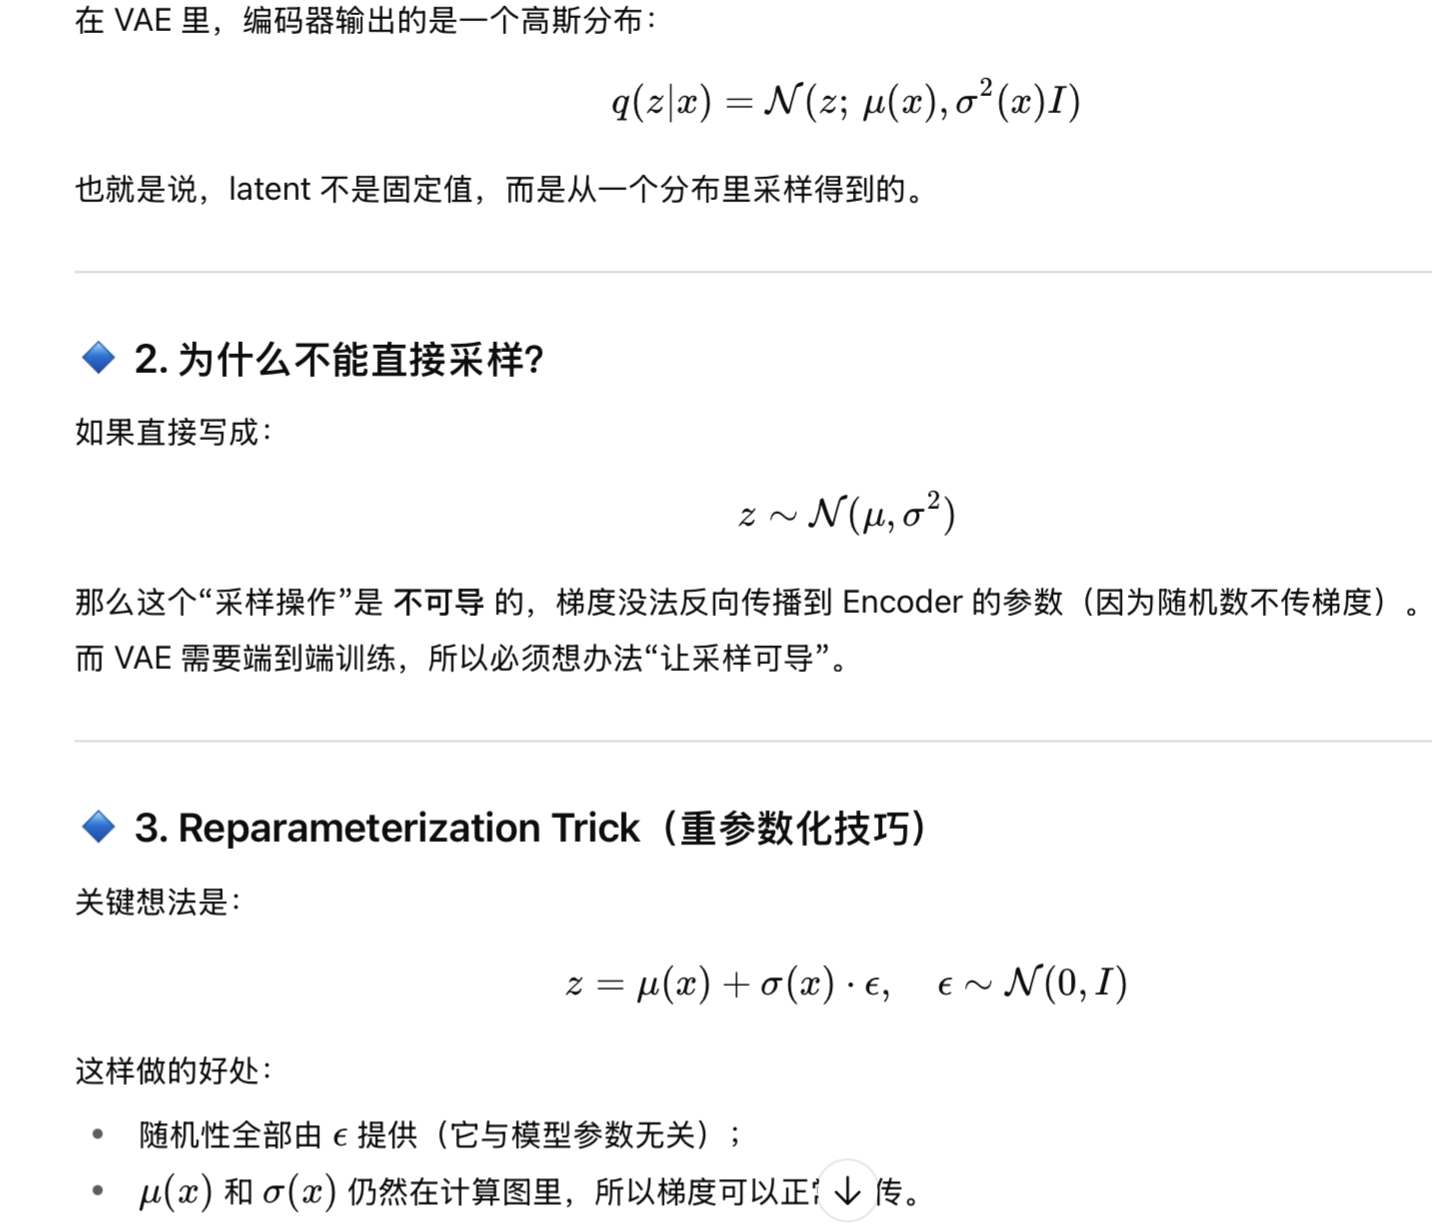

In [ ]:
from logging import log
class TinyVAE(nn.Module):
    def __init__(self, in_channels=3,z_channels=4) :
        super().__init__()

        self.encoder=TinyEncoder(in_channels=in_channels,
                                 z_channels=z_channels)

        self.decoder=TinyDecoder(out_channels=in_channels,
                                 z_channels=z_channels
                                 )

    def encode(self,x):
        mu,logvar=self.encoder(x)
        std=torch.exp(0.5 * logvar) #σ
        eps=torch.randn_like(mu)
        z= mu + eps * std
        return z,mu,logvar

    def decode(self,z):
        return self.decoder(z)

    def forward(self,x):
        z, mu, logvar=self.encode(x)
        print(z.shape)
        recon=self.decode(z)
        print(recon.shape)
        return recon,mu,logvar







In [ ]:
#time embedding

class Time_Position(nn.Module):

    def __init__(self, dim):
        super().__init__()

        self.dim=dim

    def forward(self,pos): #pos shape (half)
        device=pos.device
        half= self.dim //2
        i=torch.arange(0,half,device=device).float()
        f=torch.exp(-math.log(10000) * (i/half)) # f shape (half)
        #       (half,1)                     (1,half)
        arg=pos.float().unsqueeze(1) * f.unsqueeze(0)
        emb=torch.cat([torch.sin(arg),torch.cos(arg)],dim=-1)
        print(emb.shape)
        return emb


In [ ]:
    #convBlock

class convBlock(nn.Module):

     def __init__(self, in_size,out_size,kernel_size,n_group,padding) -> None:
        super().__init__()
        #n_group=min(1,in_size)
        self.norm=nn.GroupNorm(num_groups=n_group,num_channels=in_size)

        self.act=nn.SiLU()

        self.conv2d=nn.Conv2d(in_channels=in_size, out_channels= out_size,kernel_size=kernel_size , padding= padding)

     def forward(self,x):
        out=self.norm(x)
        out=self.act(out)
        out=self.conv2d(out)

        return out

In [ ]:
class resBlock(nn.Module):
    def __init__(self, in_size,out_size) -> None:
        super().__init__()
        self.conv_in=convBlock(in_size=in_size,out_size=out_size,kernel_size=3,n_group=8,padding=1)
        #self.embed_mlp= nn.Linear(in_features=t_dim,out_features=out_size)

        self.conv_out=convBlock(in_size=out_size,out_size=out_size,kernel_size=3,n_group=8,padding=1)

        self.residule= (nn.Conv2d(in_channels=in_size, out_channels=out_size,kernel_size=1) if in_size != out_size else nn.Identity())


    def forward(self,x):
        # t=F.silu(t_emb)
        # t=self.embed_mlp(t) [:,:,None,None]

        h=self.conv_in(x)
        #h=h+t
        h=self.conv_out(h)
        x=self.residule(x)
        result=h+x
        return result

In [ ]:
class SmallUNet(nn.Module):

    def __init__(self, in_channels,cond_channels,base_channels=64) :
        super().__init__()
        self.down1=resBlock(in_size=in_channels+cond_channels,
                               out_size=base_channels)

        self.down2=resBlock(in_size=base_channels,
                               out_size=base_channels*2)

        self.down3=resBlock(in_size=base_channels*2,
                               out_size=base_channels*4)

        self.down4=resBlock(in_size=base_channels*4,
                               out_size=base_channels*4)

        self.up1=resBlock(in_size=base_channels*4 + base_channels*4,
                          out_size=base_channels*4)

        self.up2=resBlock(in_size=base_channels*4 + base_channels*2,
                          out_size=base_channels*2)

        self.up3=resBlock(in_size=base_channels*2 + base_channels,
                          out_size=base_channels)

        self.final=nn.Conv2d(in_channels=base_channels,
                             out_channels=in_channels,
                             kernel_size=1)

        self.time_mlp=nn.Sequential(
            nn.Linear(in_features=1,out_features=32),
            nn.ReLU(),
            nn.Linear(in_features=32,
                      out_features=base_channels *4
                      )

        )

    def forward(self,x,t,cond):
        # x: noisy latent map [B, C, H, W]
        # cond: condition map [B, Ccond, H, W] (source latent expanded)
        # t: timestep tensor [B] normalized 0..1
        h=torch.cat([x,cond],dim=1
                    )
        #print(f'h shape:{h.shape}')
        d1=self.down1(h)
        #print(f'd1 pre-pool:{d1.shape}')
        d1_d=F.avg_pool2d(d1,2)
        #print(f'd1 post-pool:{d1_d.shape}')

        d2=self.down2(d1_d)
        #print(f'd2 pre-pool:{d2.shape}')

        d2_d=F.avg_pool2d(d2,2)
        #print(f'd2 post-pool:{d2_d.shape}')

        d3=self.down3(d2_d)
        #print(f'd3 pre-pool:{d3.shape}')

        d3_d=F.avg_pool2d(d3,2)
        #print(f'd3 post-pool:{d3_d.shape}')

        d4=self.down4(d3_d)
        #print(f'd4 pre-temb:{d4.shape}')

         #t: [B] -> [B,C=0] ->[B,C=base_channels*2] ->[B,C,H]->[B,C,H,W]
        t_emb=self.time_mlp(t.unsqueeze(-1)).unsqueeze(-1).unsqueeze(-1)

        d4=d4+t_emb
        #print(f'd4 post-temb:{d4.shape}')


        d4_u=F.interpolate(d4,scale_factor=2,mode="nearest")
        #print(f'd4_u:{d4_u.shape}')
        u1=self.up1(torch.cat([d4_u,d3],dim=1))
        #print(f'u1:{u1.shape}')

        u2_u=F.interpolate(u1,scale_factor=2,mode="nearest")
        #print(f'u2_u:{u2_u.shape}')
        u2=self.up2(torch.cat([u2_u,d2],dim=1))
        #print(f'u2:{u2.shape}')

        u3_u=F.interpolate(u2,scale_factor=2,mode="nearest")
        #print(f'u3_u:{u3_u.shape}')

        u3=self.up3(torch.cat([u3_u,d1],dim=1))
        #print(f'u3:{u3.shape}')


        out=self.final(u3)
        #print(f'out:{out.shape}')
        return out










In [ ]:
# U-Net like model for latent
from torch.nn import functional as F

def conv_block(in_channels,out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels=in_channels,
                  out_channels=out_channels,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU()
    )






class TinyUNet(nn.Module):
    def __init__(self, in_channels,cond_channels,base_channels=64) :
        super().__init__()
     #cond_channels:conditional latent
        self.down1=conv_block(in_channels=(in_channels + cond_channels),out_channels=base_channels)

        self.down2=conv_block(in_channels=base_channels,out_channels=base_channels*2)

        self.down3=conv_block(in_channels=base_channels*2,
                              out_channels=base_channels*4)

        self.down4=conv_block(in_channels=base_channels*4,
                              out_channels=base_channels*4)

        self.up1=conv_block(in_channels=base_channels*4 +base_channels*4,
                            out_channels=base_channels*4
                            )
        self.up2=conv_block(in_channels=base_channels *4 + base_channels *2,
                            out_channels=base_channels*2)

        self.up3=conv_block(in_channels=base_channels*2+ base_channels,
                            out_channels=base_channels)

        self.final=nn.Conv2d(in_channels=base_channels,
                             out_channels=in_channels,
                             kernel_size=1)
        self.time_mlp=nn.Sequential(
            nn.Linear(in_features=1,out_features=32),
            nn.ReLU(),
            nn.Linear(in_features=32,
                      out_features=base_channels *4
                      )


        )

    def forward(self, x,t,cond):
         # x: noisy latent map [B, C, H, W]
        # cond: condition map [B, Ccond, H, W] (source latent expanded)
        # t: timestep tensor [B] normalized 0..1
        h=torch.cat([x,cond],dim=1
                    )
        #print(f'h shape:{h.shape}')
        d1=self.down1(h)
        #print(f'd1 pre-pool:{d1.shape}')
        d1_d=F.avg_pool2d(d1,2)
        #print(f'd1 post-pool:{d1_d.shape}')

        d2=self.down2(d1_d)
        #print(f'd2 pre-pool:{d2.shape}')

        d2_d=F.avg_pool2d(d2,2)
        #print(f'd2 post-pool:{d2_d.shape}')

        d3=self.down3(d2_d)
        #print(f'd3 pre-pool:{d3.shape}')

        d3_d=F.avg_pool2d(d3,2)
        #print(f'd3 post-pool:{d3_d.shape}')

        d4=self.down4(d3_d)
        #print(f'd4 pre-temb:{d4.shape}')

         #t: [B] -> [B,C=0] ->[B,C=base_channels*2] ->[B,C,H]->[B,C,H,W]
        t_emb=self.time_mlp(t.unsqueeze(-1)).unsqueeze(-1).unsqueeze(-1)

        d4=d4+t_emb
        #print(f'd4 post-temb:{d4.shape}')


        d4_u=F.interpolate(d4,scale_factor=2,mode="nearest")
        #print(f'd4_u:{d4_u.shape}')
        u1=self.up1(torch.cat([d4_u,d3],dim=1))
        #print(f'u1:{u1.shape}')

        u2_u=F.interpolate(u1,scale_factor=2,mode="nearest")
        #print(f'u2_u:{u2_u.shape}')
        u2=self.up2(torch.cat([u2_u,d2],dim=1))
        #print(f'u2:{u2.shape}')

        u3_u=F.interpolate(u2,scale_factor=2,mode="nearest")
        #print(f'u3_u:{u3_u.shape}')

        u3=self.up3(torch.cat([u3_u,d1],dim=1))
        #print(f'u3:{u3.shape}')


        out=self.final(u3)
        #print(f'out:{out.shape}')
        return out









In [ ]:
# DDPM scheduler

def make_beta_schedule(T,beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start,beta_end,steps=T)


class SimpleScheduler(nn.Module):

    def __init__(self, T) -> None:
        super().__init__()
        self.T=T
        betas=make_beta_schedule(T)
        alphas=1.-betas
        alpha_prod= torch.cumprod(alphas,dim=0)
        self.betas=betas.to(device)
        self.alphas=alphas.to(device)
        self.alphas_prod=alpha_prod.to(device)

    def q_sample(self,x_0,t,eps=None):
        if eps is None:
            eps=torch.randn(x_0)
        alpha_hat=self.alphas_prod[t].view(-1,1,1,1)
        result=torch.sqrt(alpha_hat) * x_0  + torch.sqrt(1- alpha_hat)* eps
        return result

    def predict_prev(self,predicted_eps,x_t,t):
        beta_t=self.betas[t].view(-1,1,1,1)
        alpha_t=self.alphas[t].view(-1,1,1,1)
        alpha_hat_t=self.alphas_prod[t].view(-1,1,1,1)
        coeff1=1./torch.sqrt(alpha_t)
        coeff2=beta_t / (torch.sqrt(1-alpha_hat_t))
        x_mu=coeff1 * (x_t - coeff2 * predicted_eps)

        return x_mu






In [ ]:
# Utilitues: dataset saves
def make_transformation(size):
    transform=transforms.Compose([
     #   transforms.Resize(size),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3,[0.5]*3) #->value:[-1,1]

    ])

def save_image(tensor,fname):
    img=tensor.detach().cpu().clamp(-1,1)
    img=(img+1.0) /2.0 #->value:[0,1]
    img=transforms.ToPILImage()(img.squeeze(0))
    img.save(fname)



In [ ]:
#Traning Config

T=700
img_size=256
batch_size=128
z_dim=16

epochs_vae=20
epochs_unet=100

lr=2e-4



In [ ]:
#dataset loading

#handle the dataset
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:
#check if file empty
if os.path.exists(path):
    if not os.listdir(os.path.join(path,"img_align_celeba","img_align_celeba")):
        print(' empty file')
    else:
        print('not empty file')
else:
    print('file path not exist')

not empty file


In [ ]:
from torch.utils.data import DataLoader,Dataset
from torchvision import datasets


import numpy as np
from torch.utils.data.sampler import SubsetRandomSampler

import pandas as pd
from torchvision.io import decode_image

class CustomDatasetFromSCV(Dataset):
    def __init__(self,scv_path,data_dir,transform=None) :
        super().__init__()
        self.labels=pd.read_csv(scv_path)
        self.transform=transform
        self.data_dir=data_dir
        self.height=img_size
        self.width=img_size

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index) :
        img_path=os.path.join(self.data_dir,self.labels.iloc[index,0])
        image=decode_image(img_path) #get image size:(Tensor[image_channels, image_height, image_width])

        #resize
        image=image.unsqueeze(0) #[B=1,C,H,W]
        resized=F.interpolate(image,size=(self.height,self.width),
                              mode="bilinear",align_corners=False)
        image=resized.squeeze(0) #[C,H,W]
        if self.transform is not None:
            image=self.transform(image)

        return image

    def get_idx_of_label(self,label):
        result=[]
        for i in range(len(self.labels)):
            if self.labels.iloc[i,1] ==label:
                result.append(i)
        return result

scv_filename=os.path.join(path,"list_eval_partition.csv")
data_path=os.path.join(path,"img_align_celeba","img_align_celeba")

transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3,[0.5]*3) #->value:[-1,1]

    ])

dataset=CustomDatasetFromSCV(scv_filename,data_path,transform=None)

train_indices=dataset.get_idx_of_label(0)
if len(train_indices)==0:
    raise Exception('train_indice extraction failed')
test_indices=dataset.get_idx_of_label(2)
if len(test_indices)==0:
    raise Exception('test_indice extraction failed')

train_sampler=SubsetRandomSampler(train_indices)
test_sampler=SubsetRandomSampler(test_indices)

train_loader=DataLoader(dataset,batch_size=batch_size,sampler=train_sampler,num_workers=2)

test_loader=DataLoader(dataset,batch_size=batch_size,sampler=test_sampler,num_workers=2)

print(len(test_loader))
#print(test_loader)




156


Train VAE


  0%|          | 0/156 [00:00<?, ?it/s]

torch.Size([128, 16, 32, 32])
torch.Size([128, 3, 256, 256])


VAE epoch:0 loss:0.3054049611091614:.4f:   1%|          | 1/156 [00:02<06:12,  2.40s/it]

torch.Size([128, 16, 32, 32])
torch.Size([128, 3, 256, 256])


...

torch.Size([128, 16, 32, 32])
torch.Size([128, 3, 256, 256])


VAE epoch:19 loss:0.11086919577792287:.4f:  99%|█████████▉| 155/156 [01:14<00:00,  2.13it/s]

torch.Size([122, 16, 32, 32])
torch.Size([122, 3, 256, 256])


VAE epoch:19 loss:0.11154232284752652:.4f: 100%|██████████| 156/156 [01:15<00:00,  2.07it/s]


torch.Size([1, 16, 32, 32])
torch.Size([1, 3, 256, 256])


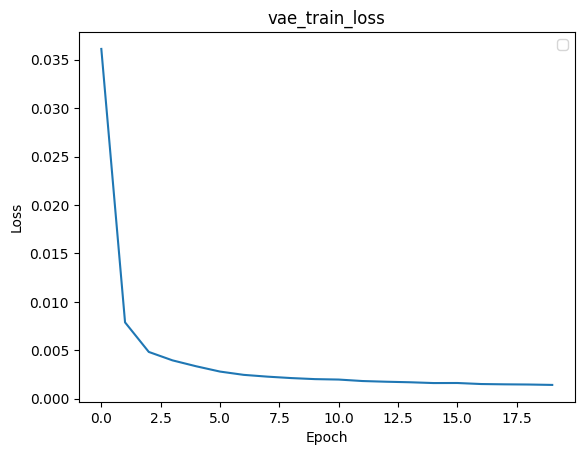

In [ ]:
#models
vae=TinyVAE(in_channels=3,z_channels=z_dim).to(device)
#unet=TinyUNet(in_channels=z_dim,cond_channels=z_dim,base_channels=64).to(device)
schedule=SimpleScheduler(T)

#optimizer
opt_vae=torch.optim.Adam(vae.parameters(),lr=lr)
#opt_unet=torch.optim.Adam(unet.parameters(),lr=lr)

#train
print("Train VAE")
vae_train_loss=[]
for epoch in range(epochs_vae):
    vae.train()
    pbar=tqdm(test_loader)
    total_loss=0.0
    for imgs in pbar:
        imgs=imgs.float()/255.0
        #imgs=imgs.float()
        imgs=imgs.to(device)
        recon,mu,logvar=vae(imgs)
        l1=F.mse_loss(imgs,recon)
        kl= -0.5 * torch.mean(1+ logvar - torch.pow(mu,2) - logvar.exp())
        loss=l1+0.0005* kl #small kl weight
        opt_vae.zero_grad()
        loss.backward()
        opt_vae.step()
        total_loss+=loss.item()
        pbar.set_description(f'VAE epoch:{epoch} loss:{total_loss/((pbar.n // batch_size)+1)}:.4f')
    out_loss=(total_loss / len(test_loader))

    vae_train_loss.append(total_loss / len(test_loader))

    #save a reconstruction
    with torch.no_grad():
        images_sample=next(iter(test_loader))
        images_sample=images_sample.float() / 255.0
        images_sample=images_sample.to(device)[:1]
        recon,_,_=vae(images_sample)
        save_image(images_sample[0:1],f'recon_input_epoch{epoch}.png')
        save_image(recon[0:1],f'recon_epoch{epoch}.png')
    torch.save(vae.state_dict(),f"vaetiny_epoch{epoch}_{out_loss}.pth")

plt.figure()
plt.plot(vae_train_loss)
plt.title("vae_train_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()








In [ ]:
t=torch.randint(0,100,(10,),device=device)
print(f't shape:{t.shape}')
print(t)

t shape:torch.Size([10])
tensor([ 4, 21, 87, 49, 28,  0, 41, 43, 91, 79])


Train Unet


UNET epoch:0 loss:51.88234227895737 :.4f: 100%|██████████| 156/156 [00:51<00:00,  3.03it/s] 

epoch[0]loss:0.6651582343456073


init cur:torch.Size([1, 16, 32, 32])
cur after reversion:torch.Size([1, 16, 32, 32])
recon:torch.Size([1, 3, 256, 256])


UNET epoch:1 loss:31.415398687124252 :.4f: 100%|██████████| 156/156 [00:51<00:00,  3.06it/s]

...

epoch[98]loss:0.33483616568339175


init cur:torch.Size([1, 16, 32, 32])
cur after reversion:torch.Size([1, 16, 32, 32])
recon:torch.Size([1, 3, 256, 256])


UNET epoch:99 loss:26.079988077282906 :.4f: 100%|██████████| 156/156 [00:51<00:00,  3.03it/s]

epoch[99]loss:0.334358821503627


init cur:torch.Size([1, 16, 32, 32])
cur after reversion:torch.Size([1, 16, 32, 32])
recon:torch.Size([1, 3, 256, 256])
finished


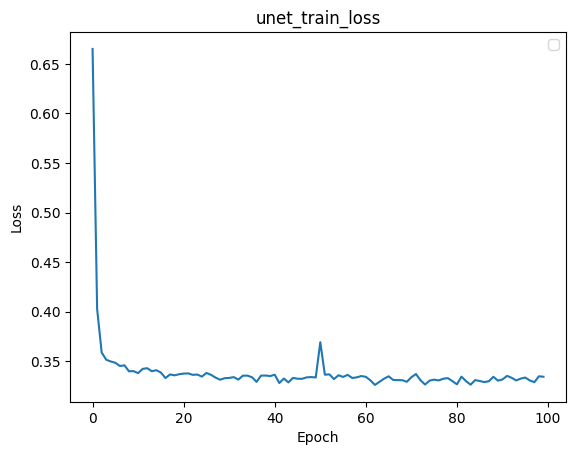

In [ ]:
print("Train Unet")
vae=TinyVAE(in_channels=3,z_channels=z_dim).to(device)
#unet=TinyUNet(in_channels=z_dim,cond_channels=z_dim,base_channels=64).to(device)
unet=SmallUNet(in_channels=z_dim,cond_channels=z_dim,base_channels=64).to(device)

opt_unet=torch.optim.Adam(unet.parameters(),lr=lr)
schedule=SimpleScheduler(T)

unet_train_loss=[]

for epoch in range(epochs_unet):
    unet.train()
    pbar=tqdm(test_loader)
    total_loss=0.0
    for imgs in pbar:
        imgs=imgs.float()/255.0
        imgs=imgs.to(device)

        source=imgs # the input of the inference(eg: a sketch),act as conditon
        target=imgs # the images with the style that we want to get

        with torch.no_grad(): #no need to train vae


            z_s,_,_=vae.encode(source)
            z_t,_,_=vae.encode(target) #size:[B,C=z_dim,H=img_size,W=img_size]
            #print(z_t.shape)

        #reshape into small latent map [B,C,H'=img_size //8, W'=img_size //8], the divider is related to the design of vae encoder
        Hs= img_size // 8
        # print(z_t.shape)
        # print(z_s.shape)
        # print(z_s.size(0))

        assert z_t.shape[2]==Hs and z_t.shape[3]==Hs
        s_zmap=z_s
        t_zmap=z_t

        # s_zmap=z_s.view(z_s.size(0),z_dim, 1,1).expand(-1,-1,Hs,Hs)
        # t_zmap=z_t.view(z_t.size(0),z_dim, 1,1).expand(-1,-1,Hs,Hs)

        #sample random t and noise
        batch=z_t.size(0)
        t=torch.randint(0,T,(batch,),device=device) #[B]
        noise=torch.randn_like(t_zmap)
        x_t=schedule.q_sample(t_zmap,t,noise) # add noise for target image

        cond=s_zmap

        #normalize t into [0,1] to apply small time embedding
        t_norm=t.float() / (T-1)
        t_norm=t_norm.to(device=device) #[B]
        #print(f't_norm:{t_norm.shape}')
        #print(f'x_t: {x_t.shape}, cond:{cond.shape}')
        noise_pred=unet(x_t,t_norm,cond)

        loss=F.mse_loss(noise_pred,noise)

        opt_unet.zero_grad()
        loss.backward()
        opt_unet.step()

        total_loss+=loss.item()
        pbar.set_description(f'UNET epoch:{epoch} loss:{total_loss/((pbar.n // batch_size)+1)} :.4f')

    unet_train_loss.append(total_loss / len(test_loader))
    out_loss=(total_loss / len(test_loader))
    print(f'epoch[{epoch}]loss:{total_loss / len(test_loader)}')

    #save checkpoints
    torch.save(unet.state_dict(),f'unet_epoch{epoch}_{out_loss}.pth')

    #quick sample: do img2img inference in small scales
    with torch.no_grad():
        images_samples=next(iter(test_loader))
        images_samples=images_samples.float() / 255.0
        images_samples=images_samples.to(device)[:1]

        #source
        z_s,_,_=vae.encode(images_samples) #[64,4,8,8]
        #s_zmap=z_s.view(1, z_dim,1,1).expand(-1,-1,Hs,Hs)
        assert z_s.shape[2]==Hs and z_s.shape[3]==Hs

        s_zmap=z_s #[64,4,8,8]

        #target
        z_t,_,_=vae.encode(images_samples) #[64,4,8,8]
        assert z_t.shape[2]==Hs and z_t.shape[3]==Hs

        #t_zmap=z_t.view(1, z_dim,1,1).expand(-1,-1,Hs,Hs)
        t_zmap=z_t #[64,4,8,8]


        #choose the noise level start_t (higher->stronger edit)
        start_t=int(0.6 *T)
        noise=torch.randn_like(t_zmap)
        x_t=schedule.q_sample(t_zmap,torch.tensor([start_t],device=device),noise)

        cur=x_t
        print(f'init cur:{cur.shape}')

        #reverse process
        for step_t in list(range(start_t,-1,-1)):
            t_step=torch.tensor([step_t],device=device)
            t_norm= t_step.float() / (T-1)
            pred_noise=unet(cur,t_norm,s_zmap)
            #cur=schedule.q_sample(cur,t_step,pred_noise)
            cur = schedule.predict_prev(pred_noise, cur, t_step)

        #decode
        print(f'cur after reversion:{cur.shape}') #(1,4,8,8)

        #z_final_vec=F.adaptive_avg_pool2d(cur,1).view(1,z_dim)
        #z_final_vec=F.adaptive_avg_pool2d(cur,1)

        #print(f'z_final_vec{z_final_vec.shape}')
        #recon=vae.decode(z_final_vec)
        recon=vae.decode(cur)
        print(f'recon:{recon.shape}')

        save_image(recon,f'sample_epoch{epoch}.png')

print("finished")

plt.figure()
plt.plot(unet_train_loss)
plt.title("unet_train_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()














In [ ]:
!zip -r model_checkpoints.zip *.pth
from google.colab import files
files.download("model_checkpoints.zip")

In [ ]:
!zip -r result.zip .


  adding: sample_epoch75.png (deflated 0%)
  adding: unet_epoch45_0.33237895121177036.pth (deflated 8%)
  adding: recon_epoch9.png (deflated 0%)
  adding: unet_epoch84_0.33100223006346285.pth (deflated 8%)
  adding: sample_epoch80.png (deflated 0%)
  adding: unet_epoch89_0.3304088526429274.pth (deflated 8%)
  adding: unet_epoch21_0.3377344115422322.pth (deflated 8%)
  adding: unet_epoch11_0.3423400162122188.pth (deflated 8%)
  adding: unet_epoch29_0.3328885246927922.pth (deflated 8%)
  adding: sample_epoch62.png (deflated 0%)
  adding: vaetiny_epoch9_0.0020290335464195754.pth (deflated 8%)
  adding: unet_epoch32_0.33149861955107784.pth (deflated 8%)
  adding: unet_epoch14_0.340979241216794.pth (deflated 8%)
  adding: sample_epoch67.png (deflated 0%)
  adding: sample_epoch97.png (deflated 0%)
  adding: unet_epoch18_0.3358251106662628.pth (deflated 8%)
  adding: unet_epoch86_0.32900862376659346.pth (deflated 8%)
  adding: recon_epoch0.png (deflated 0%)
  adding: sample_epoch25.png (defla